Analiza podatkov za 500 najbolj vrednih nogometnihi igralcev na svetu.

In [126]:
import pandas as pd
pd.set_option("display.max_rows", 16)
pd.set_option("display.min_rows", 16)
%matplotlib inline
IGRALCI = pd.read_csv("podatki/transfermarket/najvrednejsi_igralci.csv")
STATISTIKA = pd.read_csv("podatki/fbref/fbref_igralci.csv")
TEKMOVANJA = pd.read_csv("podatki/opta/moc_tekmovanj.csv")

In [127]:
IGRALCI

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost
0,1,Erling Haaland,26,Norway,Manchester City,220.0
1,2,Lamine Yamal,19,Spain,FC Barcelona,220.0
2,3,Kylian Mbappé,27,France,Real Madrid,200.0
3,4,Michael Olise,24,France,Bayern Munich,170.0
4,5,Jude Bellingham,23,England,Real Madrid,160.0
5,6,Pedri,23,Spain,FC Barcelona,150.0
6,7,Vinicius Junior,26,Brazil,Real Madrid,140.0
7,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0
...,...,...,...,...,...,...
492,493,Vasilije Kostov,18,Serbia,Red Star Belgrade,25.0


In [128]:
STATISTIKA

,fbref_id,ime,tekmovanja,tekme,min,goli,asistence,G+A
0,29dd3b2e,Jones El-Abdellaoui,"['la_liga', 'europa_league', 'copa_del_rey']",31,1181,3,0,3
1,88824111,Tay Abed,['la_liga'],7,93,0,0,0
2,2bc7f211,Abdel Abqar,"['la_liga', 'copa_del_rey']",24,1457,0,2,2
3,2ccd39ed,Akor Adams,"['la_liga', 'copa_del_rey']",33,2154,10,4,14
4,f76e6b4e,Adrián,"['la_liga', 'copa_del_rey']",6,540,0,0,0
5,4b00cd47,David Affengruber,"['la_liga', 'copa_del_rey']",39,3093,1,2,3
6,a2c1a8d3,Julen Agirrezabala,"['la_liga', 'copa_del_rey']",19,1710,0,0,0
7,8bc8829a,Lucien Agoume,"['la_liga', 'copa_del_rey']",36,2799,1,4,5
...,...,...,...,...,...,...,...,...
19581,61a5541d,Zach Zandi,['us_open_cup'],1,45,0,0,0


In [129]:
TEKMOVANJA

,tekmovanje,moc
0,English Premier League,92.60
1,German Bundesliga,86.70
2,Spanish La Liga,86.70
3,Italian Serie A,86.60
4,French Ligue 1,85.80
5,Brazilian Serie A,83.20
6,Belgian Jupiler Pro League,82.10
7,Portuguese Primeira Liga,81.50
...,...,...
321,copa_libertadores,78.86


In [130]:
zdruzeni_podatki = pd.merge(IGRALCI, STATISTIKA, on="ime", how="left")
zdruzeni_podatki

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost,fbref_id,tekmovanja,tekme,min,goli,asistence,G+A
0,1,Erling Haaland,26,Norway,Manchester City,220.0,1f44ac21,"['premier_league', 'champions_league', 'fa_cup...",52.0,4135.0,38.0,9.0,47.0
1,2,Lamine Yamal,19,Spain,FC Barcelona,220.0,82ec26c1,"['la_liga', 'champions_league', 'copa_del_rey'...",45.0,3691.0,24.0,17.0,41.0
2,3,Kylian Mbappé,27,France,Real Madrid,200.0,42fd9c7f,"['la_liga', 'champions_league', 'copa_del_rey'...",44.0,3616.0,42.0,6.0,48.0
3,4,Michael Olise,24,France,Bayern Munich,170.0,c4486bac,"['bundesliga', 'champions_league', 'dfb_pokal']",51.0,3916.0,22.0,26.0,48.0
4,5,Jude Bellingham,23,England,Real Madrid,160.0,57d88cf9,"['la_liga', 'champions_league', 'copa_del_rey'...",40.0,2720.0,8.0,5.0,13.0
5,6,Pedri,23,Spain,FC Barcelona,150.0,0d9b2d31,"['la_liga', 'champions_league', 'copa_del_rey'...",43.0,3085.0,2.0,12.0,14.0
6,7,Vinicius Junior,26,Brazil,Real Madrid,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0,74d4cec6,"['serie_a', 'coppa_italia']",36.0,2247.0,5.0,1.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,493,Vasilije Kostov,18,Serbia,Red Star Belgrade,25.0,c02be712,"['serbian_superliga', 'europa_league']",42.0,2972.0,14.0,7.0,21.0


In [131]:
#vrstic je 526 namesto 500 zato je prišlo pri združevanju do duplikatov
zdruzeni_podatki[zdruzeni_podatki.duplicated(subset=["ime"], keep=False)]

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost,fbref_id,tekmovanja,tekme,min,goli,asistence,G+A
7,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0,74d4cec6,"['serie_a', 'coppa_italia']",36.0,2247.0,5.0,1.0,6.0
8,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0,3b029691,"['ligue_1', 'champions_league', 'coupe_de_fran...",47.0,3752.0,7.0,8.0,15.0
41,41,João Pedro,24,Brazil,Chelsea FC,80.0,e8832875,"['premier_league', 'champions_league', 'fa_cup...",50.0,3676.0,20.0,6.0,26.0
42,41,João Pedro,24,Brazil,Chelsea FC,80.0,cd51f56f,"['serie_a_bra', 'copa_sudamericana']",17.0,1332.0,0.0,1.0,1.0
43,41,João Pedro,24,Brazil,Chelsea FC,80.0,31d1ed52,"['serie_a_bra', 'copa_sudamericana']",11.0,757.0,1.0,0.0,1.0
44,41,João Pedro,24,Brazil,Chelsea FC,80.0,81255c03,"['liga_mx', 'leagues_cup']",36.0,3209.0,28.0,1.0,29.0
55,52,Gabriel,28,Brazil,Arsenal FC,75.0,4fd28619,"['serie_a_bra', 'copa_sudamericana']",14.0,1038.0,0.0,0.0,0.0
56,52,Gabriel,28,Brazil,Arsenal FC,75.0,8dc3be2b,['serie_a_bra'],25.0,1592.0,5.0,2.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,472,André,25,Brazil,Wolverhampton Wanderers,25.0,867660e8,['serie_a_bra'],9.0,315.0,2.0,0.0,2.0


In [132]:

zdruzeni_podatki[zdruzeni_podatki.isna().any(axis=1)]

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost,fbref_id,tekmovanja,tekme,min,goli,asistence,G+A
6,7,Vinicius Junior,26,Brazil,Real Madrid,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,12,Julián Alvarez,26,Argentina,Atlético de Madrid,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,23,Fermín López,23,Spain,FC Barcelona,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,32,Yan Diomande,19,Cote d'Ivoire,RB Leipzig,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,43,Hugo Ekitiké,24,France,Liverpool FC,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,45,Nico Paz,21,Argentina,Como 1907,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,46,Estêvão,19,Brazil,Chelsea FC,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,53,Jérémy Doku,24,Belgium,Manchester City,75.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,474,Javi Guerra,23,Spain,Valencia CF,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
#imena nekaterih igralcev se v tabelah razlikujejo le za naglase, zato jih odstranimo s pomožno funkcijo
import unicodedata

def pocisti_ime(ime):
    niz = ''.join(c for c in unicodedata.normalize('NFKD', str(ime)) if not unicodedata.combining(c))
    return niz.replace("'", "").lower().strip()

IGRALCI["ime"] = IGRALCI["ime"].apply(pocisti_ime)

import unicodedata

def pocisti_ime(ime):
    niz = ''.join(c for c in unicodedata.normalize('NFKD', str(ime)) if not unicodedata.combining(c))
    return niz.replace("'", "").lower().strip()

STATISTIKA["ime"] = STATISTIKA["ime"].apply(pocisti_ime)


#Nekateri igralci imajo na transfermarket in fbref drugače zapisano ime, zato jih bom s slovarjem poenotil, da ne bom imel NaN
popravki = {
    "nico paz": "nicolas paz",
    "estevao": "estevao willian",
    "junior kroupi": "eli junior kroupi",
    "yann bisseck":	"yann aurel bisseck",
    "ederson": "ederson silva",
    "pio esposito": "francesco esposito",
    "samu aghehowa": "samu omorodion",
    "nico gonzalez": "nicolas gonzalez",
    "ilya zabarnyi": "illia zabarnyi",
    "ferdi kadıoglu": "ferdi kadioglu",
    "evan ndicka": "obite ndicka",
    "bremer": "gleison bremer",
    "savinho": "savio",
    "konstantinos karetsas": "kos karetsas",
    "yegor yarmolyuk": "yehor yarmoliuk",
    "matvey safonov": "matvei safonov",
    "fabian ruiz": "fabian ruiz pena",
    "gabri veiga": "gabriel veiga",
    "taty castellanos": "valentin castellanos",
    "kang-in lee": "lee kang-in",
    "aleksey batrakov": "aleksei batrakov",
    "karim coulibaly": "abdoul coulibaly",
    "anatoliy trubin": "anatolii trubin",
    "emmanuel emegha": "emanuel emegha",
    "georgiy sudakov": "heorhiy sudakov",
    "matvey kislyak": "matvei kisliak",
    "hakon arnar haraldsson": "hakon haraldsson",
    "javi guerra": "javier guerra",
    "jose manuel lopez": "flaco lopez",
    "jean-matteo bahoya": "jean matteo bahoya",
    "josh acheampong": "joshua acheampong",
    "josh king": "joshua king",
    "gabriel": "gabriel magalhaes"
}
IGRALCI["ime"] = IGRALCI["ime"].replace(popravki)
zdruzeni_podatki = pd.merge(IGRALCI, STATISTIKA, on="ime", how="left").drop(columns=["fbref_id"])

zdruzeni_podatki = zdruzeni_podatki[(zdruzeni_podatki["ime"] != "romulo") | (zdruzeni_podatki["tekme"] == 32)]
zdruzeni_podatki = zdruzeni_podatki.sort_values(by="tekme", ascending=False)

zdruzeni_podatki = zdruzeni_podatki.drop_duplicates(subset=["uvrstitev"], keep="first")
zdruzeni_podatki = zdruzeni_podatki.set_index("uvrstitev").sort_values(by="uvrstitev")
zdruzeni_podatki

,ime,starost,drzavljanstvo,klub,vrednost,tekmovanja,tekme,min,goli,asistence,G+A
uvrstitev,,,,,,,,,,,
1,erling haaland,26,Norway,Manchester City,220.0,"['premier_league', 'champions_league', 'fa_cup...",52,4135,38,9,47
2,lamine yamal,19,Spain,FC Barcelona,220.0,"['la_liga', 'champions_league', 'copa_del_rey'...",45,3691,24,17,41
3,kylian mbappe,27,France,Real Madrid,200.0,"['la_liga', 'champions_league', 'copa_del_rey'...",44,3616,42,6,48
4,michael olise,24,France,Bayern Munich,170.0,"['bundesliga', 'champions_league', 'dfb_pokal']",51,3916,22,26,48
5,jude bellingham,23,England,Real Madrid,160.0,"['la_liga', 'champions_league', 'copa_del_rey'...",40,2720,8,5,13
6,pedri,23,Spain,FC Barcelona,150.0,"['la_liga', 'champions_league', 'copa_del_rey'...",43,3085,2,12,14
7,vinicius junior,26,Brazil,Real Madrid,140.0,"['la_liga', 'champions_league', 'copa_del_rey'...",53,4235,22,10,32
8,vitinha,26,Portugal,Paris Saint-Germain,140.0,"['ligue_1', 'champions_league', 'coupe_de_fran...",47,3752,7,8,15
...,...,...,...,...,...,...,...,...,...,...,...


Osnovne značilnosti 500 najbolj vrednih nogometnih igralcev

In [134]:
opis = zdruzeni_podatki[["starost", "vrednost", "tekme", "min", "goli", "asistence", "G+A"]].describe().round(2).drop(index="count")
opis = opis.rename(index={
    "mean": "povprecje",
    "std": "standardni odklon",
    "25%": "1. kvartil",
    "50%": "mediana",
    "75%": "3. kvartil"
}).rename(columns={
    "min": "minute"
})
opis

,starost,vrednost,tekme,minute,goli,asistence,G+A
povprecje,24.19,44.06,38.39,2702.78,6.25,4.08,10.33
standardni odklon,2.95,26.63,9.43,917.66,6.86,3.80,9.21
min,16.00,23.00,1.00,80.00,0.00,0.00,0.00
1. kvartil,22.00,28.00,33.00,2009.50,2.00,1.00,4.00
mediana,24.00,35.00,39.00,2750.50,4.00,3.00,8.00
3. kvartil,26.00,50.00,45.00,3341.75,9.00,6.00,14.25
max,33.00,220.00,67.00,4643.00,60.00,26.00,67.00


drzavljanstvo
England             13.2
France               9.8
Spain                8.8
Brazil               7.8
Netherlands          6.0
Germany              5.8
Portugal             4.8
Italy                4.2
                    ... 
Guinea               0.2
Montenegro           0.2
Korea, South         0.2
Armenia              0.2
Northern Ireland     0.2
Iceland              0.2
Mozambique           0.2
Mexico               0.2
Name: proportion, Length: 59, dtype: float64

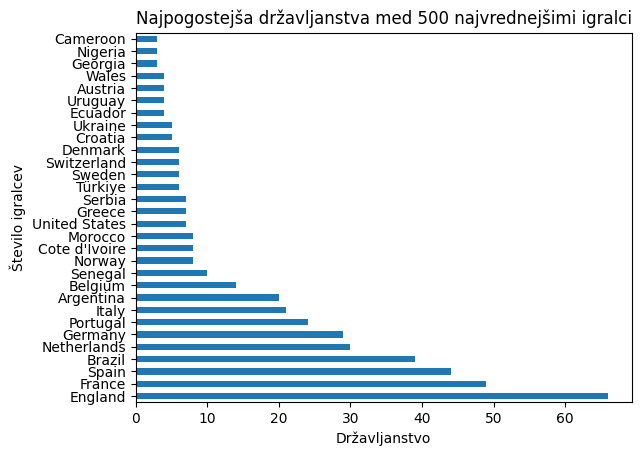

In [148]:
top_drzavljanstva = (zdruzeni_podatki["drzavljanstvo"].value_counts().head(30))

top_drzavljanstva.plot(
    kind="barh", 
    title="Najpogostejša državljanstva med 500 najvrednejšimi igralci",
    xlabel="Državljanstvo",
    ylabel="Število igralcev"
)

delezi_drzavljanstev = (zdruzeni_podatki["drzavljanstvo"].value_counts(normalize=True)*100)
delezi_drzavljanstev